In [1]:
!pip install --upgrade scikit-learn==1.9.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 60.7 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


In [2]:
# ============================================
# STEP 1: Mount Google Drive
# ============================================
# This gives Colab access to files stored in your Google Drive,
# so we can load the IoTNet24 dataset and later save models/scaler there.

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# ============================================
# STEP 2: Import Required Libraries
# ============================================

# For data handling
import pandas as pd
import numpy as np

# For visualization
import matplotlib.pyplot as plt
import seaborn as sns

# For preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder, OneHotEncoder

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)

# For saving models
import joblib
import os

# Ignore harmless warnings for a cleaner notebook
import warnings
warnings.filterwarnings('ignore')

# Set consistent plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

print("All libraries imported successfully!")

All libraries imported successfully!


In [4]:
# ============================================
# STEP 3: Load Dataset from Google Drive
# ============================================

file_path = '/content/drive/MyDrive/Machine Learning Projects/iotnet24_traffic.csv'

# Load the dataset into a pandas DataFrame
df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")

Dataset loaded successfully!
Shape: (23145, 18)


In [5]:
# ============================================
# STEP 4: Initial Dataset Inspection
# ============================================

# 1. Shape
print("Dataset Shape:", df.shape)

# 2. First 5 rows
print("\nFirst 5 Rows:")
df.head()
# 3. Dataset info (column names, dtypes, non-null counts)
print("Dataset Info:")
df.info()
# 4. Missing values per column
print("Missing Values per Column:")
df.isnull().sum().sort_values(ascending=False)

Dataset Shape: (23145, 18)

First 5 Rows:
Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23145 entries, 0 to 23144
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     23145 non-null  int64  
 1   id.orig_h      23145 non-null  object 
 2   id.orig_p      23145 non-null  int64  
 3   id.resp_h      23145 non-null  object 
 4   id.resp_p      23145 non-null  int64  
 5   proto          23145 non-null  object 
 6   service        1847 non-null   object 
 7   duration       5321 non-null   float64
 8   orig_bytes     5321 non-null   float64
 9   resp_bytes     5321 non-null   float64
 10  conn_state     23145 non-null  object 
 11  missed_bytes   23145 non-null  int64  
 12  history        23145 non-null  object 
 13  orig_pkts      23145 non-null  int64  
 14  orig_ip_bytes  23145 non-null  int64  
 15  resp_pkts      23145 non-null  int64  
 16  resp_ip_bytes  23145 non-null  int64  

,0
service,21298
resp_bytes,17824
duration,17824
orig_bytes,17824
id.orig_h,0
Unnamed: 0,0
proto,0
id.resp_p,0
id.resp_h,0
id.orig_p,0


In [6]:
# ============================================
# STEP 4.5: Drop Irrelevant/Unusable Columns
# ============================================
# - 'Unnamed: 0': leftover index column, no information
# - 'id.orig_h', 'id.resp_h': specific IP addresses — won't generalize
#   to new devices/attackers, risk of the model memorizing rather than learning
# - 'service': 92% missing, too sparse to be reliable
# - 'history': complex encoded string, skipped for simplicity (matches the
#   dataset author's own recommended 6 key features)

cols_to_drop = ['Unnamed: 0', 'id.orig_h', 'id.resp_h', 'service', 'history']
df = df.drop(columns=cols_to_drop)

print("Irrelevant columns dropped.")
print(f"New shape: {df.shape}")

Irrelevant columns dropped.
New shape: (23145, 13)


Label Value Counts:
label
Malicious    21222
Benign        1923
Name: count, dtype: int64

Label Class Percentage:
label
Malicious    91.69151
Benign        8.30849
Name: proportion, dtype: float64


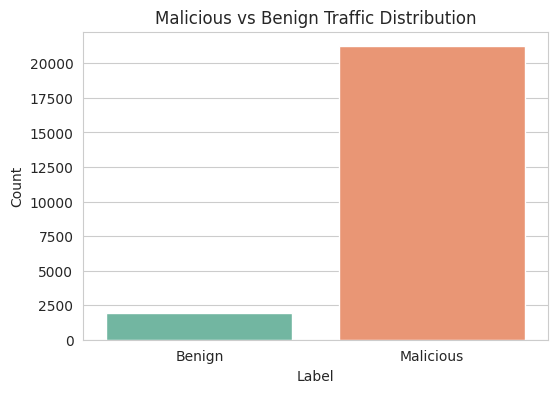

In [7]:
# ============================================
# STEP 5.1: Target Class Distribution
# ============================================

print("Label Value Counts:")
print(df['label'].value_counts())
print("\nLabel Class Percentage:")
print(df['label'].value_counts(normalize=True) * 100)

plt.figure(figsize=(6, 4))
sns.countplot(x='label', data=df, palette='Set2')
plt.title('Malicious vs Benign Traffic Distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

In [8]:
# ============================================
# STEP 5.2: Connection State by Label
# ============================================
# Shows which connection states are associated with malicious vs benign traffic

pd.crosstab(df['conn_state'], df['label'])

label,Benign,Malicious
conn_state,,
OTH,0,14260
RSTR,0,53
S0,1074,5321
S1,0,4
S3,0,1584
SF,849,0


In [9]:
# ============================================
# STEP 5.3: Protocol (proto) by Label
# ============================================
pd.crosstab(df['proto'], df['label'])

label,Benign,Malicious
proto,,
tcp,111,21220
udp,1812,2


In [10]:
# ============================================
# STEP 5.4: Numeric Feature Distributions (text-based)
# ============================================

numeric_features = ['id.orig_p', 'id.resp_p', 'missed_bytes', 'orig_pkts',
                     'orig_ip_bytes', 'resp_pkts', 'resp_ip_bytes']

df[numeric_features].describe()

,id.orig_p,id.resp_p,missed_bytes,orig_pkts,orig_ip_bytes,resp_pkts,resp_ip_bytes
count,23145.000000,23145.000000,23145.000000,23145.000000,2.314500e+04,23145.000000,23145.000000
mean,56409.651847,2324.573558,2.127112,6.375157,3.664312e+03,0.611017,111.218967
std,17176.590987,5362.933817,102.490787,178.548725,5.003762e+05,8.305898,2713.082822
min,0.000000,1.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000
25%,53622.000000,80.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000
50%,65279.000000,80.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000
75%,65279.000000,6667.000000,0.000000,1.000000,7.600000e+01,0.000000,0.000000
max,65279.000000,63798.000000,5792.000000,18444.000000,7.606306e+07,1070.000000,168910.000000


In [11]:
# ============================================
# STEP 5.5: Correlation Heatmap (Numeric Features)
# ============================================
numeric_cols = ['id.resp_p', 'duration', 'orig_bytes', 'resp_bytes',
                 'missed_bytes', 'orig_pkts', 'orig_ip_bytes', 'resp_pkts', 'resp_ip_bytes']

plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols + ['label']].corr(), cmap='coolwarm', center=0, annot=True, fmt='.2f')
plt.title('Correlation Heatmap - Numeric Features (IoTNet24)')
plt.tight_layout()
plt.savefig('iotnet24_correlation_heatmap.png', dpi=150)
plt.show()

ValueError: could not convert string to float: 'Benign'

<Figure size 1000x800 with 0 Axes>

In [12]:
# ============================================
# STEP 5.6: Outlier Detection (IQR method)
# ============================================
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"{col}: {len(outliers)} outliers (bounds: {lower_bound:.2f} to {upper_bound:.2f})")

id.resp_p: 121 outliers (bounds: -9800.50 to 16547.50)
duration: 1603 outliers (bounds: 0.46 to 4.77)
orig_bytes: 43 outliers (bounds: -93.00 to 155.00)
resp_bytes: 19 outliers (bounds: -364.50 to 607.50)
missed_bytes: 11 outliers (bounds: 0.00 to 0.00)
orig_pkts: 4382 outliers (bounds: -1.50 to 2.50)
orig_ip_bytes: 1720 outliers (bounds: -114.00 to 190.00)
resp_pkts: 2490 outliers (bounds: 0.00 to 0.00)
resp_ip_bytes: 2490 outliers (bounds: 0.00 to 0.00)


In [13]:
# ============================================
# STEP 6.1: Check for Duplicate Rows
# ============================================

duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 15324


In [14]:
# ============================================
# STEP 6.2: Investigate Duplicates Before Deciding
# ============================================

dup_rows = df[df.duplicated(keep=False)]
print("Label distribution among duplicate rows:")
print(dup_rows['label'].value_counts(normalize=True) * 100)

print("\nLabel distribution in full dataset:")
print(df['label'].value_counts(normalize=True) * 100)

Label distribution among duplicate rows:
label
Malicious    92.115347
Benign        7.884653
Name: proportion, dtype: float64

Label distribution in full dataset:
label
Malicious    91.69151
Benign        8.30849
Name: proportion, dtype: float64


In [15]:
# ============================================
# STEP 6.3: Drop Duplicates + Handle Missing Values
# ============================================
df = df.drop_duplicates()

# Impute duration/orig_bytes/resp_bytes missing values as 0
# (missing = no data exchanged, e.g. failed/incomplete connections)
df[['duration', 'orig_bytes', 'resp_bytes']] = df[['duration', 'orig_bytes', 'resp_bytes']].fillna(0)

print(f"Shape after cleaning: {df.shape}")
print(f"Remaining missing values: {df.isnull().sum().sum()}")
print(f"\nNew label distribution:")
print(df['label'].value_counts(normalize=True) * 100)

Shape after cleaning: (7821, 13)
Remaining missing values: 0

New label distribution:
label
Malicious    90.077995
Benign        9.922005
Name: proportion, dtype: float64


In [16]:
# ============================================
# STEP 7: Drop id.orig_p (ephemeral source port, no real signal)
# ============================================
# Source ports are typically assigned semi-randomly by the OS for outgoing
# connections — unlike destination port (id.resp_p), which reflects what
# service was targeted, the source port carries little to no attack signal.

df = df.drop(columns=['id.orig_p'])
print(f"Shape: {df.shape}")

Shape: (7821, 12)


In [17]:
# ============================================
# STEP 8: Encode Categorical Variables
# ============================================
# proto: 2 categories (tcp/udp) -> Label Encoding (binary, no ordinal issue)
# conn_state: 6 categories, no natural order -> One-Hot Encoding

# Label encode proto
le_proto = LabelEncoder()
df['proto'] = le_proto.fit_transform(df['proto'])

# One-hot encode conn_state
df = pd.get_dummies(df, columns=['conn_state'], prefix='conn_state')

# Label encode target (Malicious=1, Benign=0 -- confirm mapping)
le_label = LabelEncoder()
df['label'] = le_label.fit_transform(df['label'])
print("Label mapping:", dict(zip(le_label.classes_, le_label.transform(le_label.classes_))))

print(f"\nShape after encoding: {df.shape}")
print(df.columns.tolist())

Label mapping: {'Benign': np.int64(0), 'Malicious': np.int64(1)}

Shape after encoding: (7821, 17)
['id.resp_p', 'proto', 'duration', 'orig_bytes', 'resp_bytes', 'missed_bytes', 'orig_pkts', 'orig_ip_bytes', 'resp_pkts', 'resp_ip_bytes', 'label', 'conn_state_OTH', 'conn_state_RSTR', 'conn_state_S0', 'conn_state_S1', 'conn_state_S3', 'conn_state_SF']


In [18]:
# ============================================
# STEP 9: Quick Multicollinearity Check
# ============================================
# We already know conn_state is a near-perfect predictor from EDA —
# just confirming nothing else is redundant before splitting.

X = df.drop(columns=['label'])
y = df['label']

corr_with_target = X.corrwith(y).sort_values(ascending=False)
print("Correlation with label:")
print(corr_with_target)

Correlation with label:
conn_state_S0      0.307139
id.resp_p          0.298003
conn_state_S3      0.167255
conn_state_OTH     0.036802
conn_state_RSTR    0.027414
conn_state_S1      0.007508
duration           0.007247
orig_bytes         0.003882
orig_ip_bytes      0.003675
resp_pkts         -0.013000
orig_pkts         -0.013013
missed_bytes      -0.107623
resp_ip_bytes     -0.109069
resp_bytes        -0.115515
conn_state_SF     -0.831930
proto             -0.939460
dtype: float64


In [19]:
# ============================================
# STEP 10-11: Train-Test Split (Stratified) + Scaling
# ============================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"X_train: {X_train_scaled.shape}, X_test: {X_test_scaled.shape}")
print(f"\nTrain label ratio:\n{y_train.value_counts(normalize=True)*100}")
print(f"\nTest label ratio:\n{y_test.value_counts(normalize=True)*100}")

X_train: (6256, 16), X_test: (1565, 16)

Train label ratio:
label
1    90.073529
0     9.926471
Name: proportion, dtype: float64

Test label ratio:
label
1    90.095847
0     9.904153
Name: proportion, dtype: float64


In [20]:
# ============================================
# STEP 12: Initialize All 8 Models
# ============================================
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000),
    'KNN': KNeighborsClassifier(),
    'Naive Bayes': GaussianNB(),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=42),
    'SVM': SVC(class_weight='balanced', probability=True, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42)
}

# ============================================
# STEP 13: Train and Evaluate Baseline Models
# ============================================
baseline_results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    baseline_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    })
    print(f"{name} done.")

baseline_df = pd.DataFrame(baseline_results).sort_values(by='F1-Score', ascending=False)
print("\n=== Baseline Results (Before Tuning) ===")
baseline_df

Logistic Regression done.
KNN done.
Naive Bayes done.
Decision Tree done.
Random Forest done.
SVM done.
Gradient Boosting done.
AdaBoost done.

=== Baseline Results (Before Tuning) ===


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
6,Gradient Boosting,0.998722,1.000000,0.998582,0.999290,0.999959
7,AdaBoost,0.998722,1.000000,0.998582,0.999290,0.999977
4,Random Forest,0.997444,0.998582,0.998582,0.998582,0.999973
1,KNN,0.996805,0.997874,0.998582,0.998228,0.992830
3,Decision Tree,0.996805,0.997874,0.998582,0.998228,0.989613
0,Logistic Regression,0.977636,0.999274,0.975887,0.987442,0.999318
5,SVM,0.968051,1.000000,0.964539,0.981949,0.973965
2,Naive Bayes,0.965495,0.997067,0.964539,0.980534,0.984324


In [21]:
# ============================================
# STEP 13.5: Feature Importance Check (Random Forest)
# ============================================
# Confirms WHAT is actually driving these near-perfect scores —
# should align with our EDA findings (conn_state, proto), not something
# unexpected that might indicate a data leak we missed.

rf_check = models['Random Forest']
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_check.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importance_df)

            Feature  Importance
0         id.resp_p    0.339310
1             proto    0.246399
15    conn_state_SF    0.106323
3        orig_bytes    0.098629
7     orig_ip_bytes    0.073964
6         orig_pkts    0.060577
9     resp_ip_bytes    0.019854
14    conn_state_S3    0.018146
2          duration    0.010757
4        resp_bytes    0.010636
8         resp_pkts    0.008555
12    conn_state_S0    0.004058
10   conn_state_OTH    0.002156
11  conn_state_RSTR    0.000624
13    conn_state_S1    0.000012
5      missed_bytes    0.000000


In [22]:
# ============================================
# STEP 14.0: Define Hyperparameter Grids (needed in this notebook too)
# ============================================
param_grids = {
    'Logistic Regression': {
        'C': [0.01, 0.1, 1, 10],
        'penalty': ['l2'],
        'solver': ['lbfgs']
    },
    'KNN': {
        'n_neighbors': [3, 5, 7, 9, 11],
        'weights': ['uniform', 'distance']
    },
    'Naive Bayes': {
        'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6]
    },
    'Decision Tree': {
        'max_depth': [3, 5, 7, 10, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    'Random Forest': {
        'n_estimators': [100, 200],
        'max_depth': [5, 10, None],
        'min_samples_split': [2, 5]
    },
    'SVM': {
        'C': [0.1, 1, 10],
        'kernel': ['rbf', 'linear'],
        'gamma': ['scale', 'auto']
    },
    'Gradient Boosting': {
        'n_estimators': [100, 200],
        'learning_rate': [0.01, 0.1, 0.2],
        'max_depth': [3, 5]
    },
    'AdaBoost': {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.1, 1.0]
    }
}

print("Hyperparameter grids defined.")

Hyperparameter grids defined.


In [24]:
# ============================================
# STEP 14: Hyperparameter Tuning with GridSearchCV
# ============================================
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

tuned_models = {}
tuned_results = []

for name, model in models.items():
    print(f"Tuning {name}...")
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grids[name],
        scoring='f1',
        cv=cv_strategy,
        n_jobs=-1
    )
    grid_search.fit(X_train_scaled, y_train)

    best_model = grid_search.best_estimator_
    tuned_models[name] = best_model

    y_pred = best_model.predict(X_test_scaled)
    y_proba = best_model.predict_proba(X_test_scaled)[:, 1]

    tuned_results.append({
        'Model': name,
        'Best Params': grid_search.best_params_,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    })
    print(f"  Done. Best F1 (CV): {grid_search.best_score_:.4f}")

tuned_df = pd.DataFrame(tuned_results).sort_values(by='F1-Score', ascending=False)
print("\n=== Tuned Results (After Tuning) ===")
tuned_df

Tuning Logistic Regression...
  Done. Best F1 (CV): 0.9919
Tuning KNN...
  Done. Best F1 (CV): 0.9999
Tuning Naive Bayes...
  Done. Best F1 (CV): 0.9880
Tuning Decision Tree...
  Done. Best F1 (CV): 0.9999
Tuning Random Forest...
  Done. Best F1 (CV): 0.9998
Tuning SVM...
  Done. Best F1 (CV): 0.9980
Tuning Gradient Boosting...
  Done. Best F1 (CV): 0.9999
Tuning AdaBoost...
  Done. Best F1 (CV): 1.0000

=== Tuned Results (After Tuning) ===


,Model,Best Params,Accuracy,Precision,Recall,F1-Score,ROC-AUC
6,Gradient Boosting,"{'learning_rate': 0.2, 'max_depth': 5, 'n_esti...",0.998722,1.000000,0.998582,0.999290,0.999998
7,AdaBoost,"{'learning_rate': 1.0, 'n_estimators': 200}",0.998722,1.000000,0.998582,0.999290,0.999977
4,Random Forest,"{'max_depth': 10, 'min_samples_split': 2, 'n_e...",0.997444,0.998582,0.998582,0.998582,0.999973
1,KNN,"{'n_neighbors': 3, 'weights': 'uniform'}",0.996805,0.997874,0.998582,0.998228,0.992830
3,Decision Tree,"{'max_depth': 7, 'min_samples_leaf': 1, 'min_s...",0.996805,0.997874,0.998582,0.998228,0.989613
5,SVM,"{'C': 1, 'gamma': 'auto', 'kernel': 'rbf'}",0.991054,0.997151,0.992908,0.995025,0.999680
0,Logistic Regression,"{'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}",0.978275,0.999274,0.976596,0.987805,0.999250
2,Naive Bayes,{'var_smoothing': 1e-09},0.965495,0.997067,0.964539,0.980534,0.984324


In [25]:
# ============================================
# STEP 15.1: Before vs After Comparison Table
# ============================================
comparison_df = baseline_df[['Model', 'Accuracy', 'F1-Score']].merge(
    tuned_df[['Model', 'Accuracy', 'F1-Score']],
    on='Model', suffixes=(' (Before)', ' (After)')
)
comparison_df['F1 Change'] = comparison_df['F1-Score (After)'] - comparison_df['F1-Score (Before)']
comparison_df['Tuning Helped?'] = comparison_df['F1 Change'].apply(
    lambda x: 'Yes' if x > 0 else ('No Change' if x == 0 else 'No - Worse!')
)
comparison_df = comparison_df.sort_values(by='F1-Score (After)', ascending=False)
print(comparison_df)

                 Model  Accuracy (Before)  F1-Score (Before)  \
0    Gradient Boosting           0.998722           0.999290   
1             AdaBoost           0.998722           0.999290   
2        Random Forest           0.997444           0.998582   
3                  KNN           0.996805           0.998228   
4        Decision Tree           0.996805           0.998228   
6                  SVM           0.968051           0.981949   
5  Logistic Regression           0.977636           0.987442   
7          Naive Bayes           0.965495           0.980534   

   Accuracy (After)  F1-Score (After)  F1 Change Tuning Helped?  
0          0.998722          0.999290   0.000000      No Change  
1          0.998722          0.999290   0.000000      No Change  
2          0.997444          0.998582   0.000000      No Change  
3          0.996805          0.998228   0.000000      No Change  
4          0.996805          0.998228   0.000000      No Change  
6          0.991054        

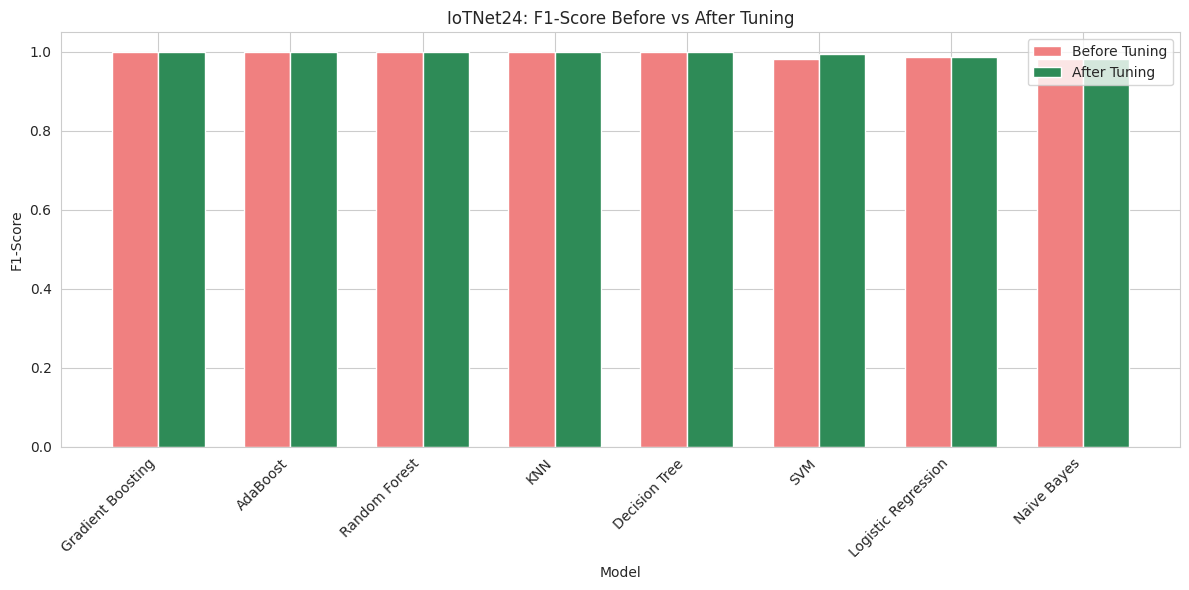

Saved.


In [26]:
# ============================================
# STEP 15.2: Before vs After Visualization
# ============================================
plt.figure(figsize=(12, 6))
x = np.arange(len(comparison_df))
width = 0.35
plt.bar(x - width/2, comparison_df['F1-Score (Before)'], width, label='Before Tuning', color='lightcoral')
plt.bar(x + width/2, comparison_df['F1-Score (After)'], width, label='After Tuning', color='seagreen')
plt.xlabel('Model'); plt.ylabel('F1-Score')
plt.title('IoTNet24: F1-Score Before vs After Tuning')
plt.xticks(x, comparison_df['Model'], rotation=45, ha='right')
plt.legend(); plt.tight_layout()
plt.savefig('iotnet24_before_after_tuning_f1.png', dpi=150)
plt.show()
print("Saved.")

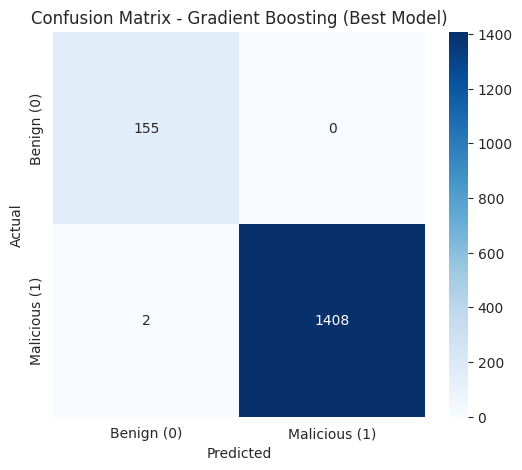

[[ 155    0]
 [   2 1408]]
True Negatives (Benign correct): 155, False Positives: 0
False Negatives: 2, True Positives (Malicious correct): 1408


In [27]:
# ============================================
# STEP 16.1: Confusion Matrix - Gradient Boosting
# ============================================
best_model = tuned_models['Gradient Boosting']
y_pred_best = best_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign (0)', 'Malicious (1)'],
            yticklabels=['Benign (0)', 'Malicious (1)'])
plt.title('Confusion Matrix - Gradient Boosting (Best Model)')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.savefig('iotnet24_confusion_matrix.png', dpi=150)
plt.show()

print(cm)
print(f"True Negatives (Benign correct): {cm[0][0]}, False Positives: {cm[0][1]}")
print(f"False Negatives: {cm[1][0]}, True Positives (Malicious correct): {cm[1][1]}")

In [28]:
# ============================================
# STEP 16.1: Create Directory Structure
# ============================================
import os

local_dir = 'saved_models/notebook2'
drive_dir = '/content/drive/MyDrive/Machine Learning Projects/saved_models/notebook2'
os.makedirs(local_dir, exist_ok=True)
os.makedirs(drive_dir, exist_ok=True)

print(f"Local directory ready: {local_dir}")
print(f"Drive directory ready: {drive_dir}")

Local directory ready: saved_models/notebook2
Drive directory ready: /content/drive/MyDrive/Machine Learning Projects/saved_models/notebook2


In [30]:
# ============================================
# STEP 16.2: Save Feature Info for Streamlit
# ============================================
feature_info = pd.DataFrame({
    'min': X.min(),
    'max': X.max(),
    'mean': X.mean(),
    'dtype': X.dtypes
})

feature_info.to_csv(os.path.join(local_dir, 'iotnet24_feature_info.csv'))
feature_info.to_csv(os.path.join(drive_dir, 'iotnet24_feature_info.csv'))

print("Feature info saved.")
print(feature_info)

Feature info saved.
                   min           max          mean    dtype
id.resp_p            1         63798   6667.440225    int64
proto                0             1      0.089119    int64
duration           0.0  48976.819063     15.516259  float64
orig_bytes         0.0    75546624.0  10059.638282  float64
resp_bytes         0.0      164266.0    236.603376  float64
missed_bytes         0          5792      6.294847    int64
orig_pkts            0         18444     18.718067    int64
orig_ip_bytes        0      76063056  10832.804117    int64
resp_pkts            0          1070      1.770490    int64
resp_ip_bytes        0        168910    326.268124    int64
conn_state_OTH   False          True      0.012147     bool
conn_state_RSTR  False          True      0.006777     bool
conn_state_S0    False          True      0.707199     bool
conn_state_S1    False          True      0.000511     bool
conn_state_S3    False          True      0.202532     bool
conn_state_SF    Fal

In [29]:
# ============================================
# Verify all files were saved correctly
# ============================================
print("Local files:")
print(os.listdir(local_dir))

print("\nDrive files:")
print(os.listdir(drive_dir))

Local files:
[]

Drive files:
['iotnet24_logistic_regression.pkl', 'iotnet24_naive_bayes.pkl', 'iotnet24_decision_tree.pkl', 'iotnet24_knn.pkl', 'iotnet24_svm.pkl', 'iotnet24_gradient_boosting.pkl', 'iotnet24_random_forest.pkl', 'iotnet24_adaboost.pkl', 'iotnet24_scaler.pkl', 'iotnet24_label_encoder.pkl', 'iotnet24_feature_info.csv', 'iotnet24_proto_encoder.pkl']


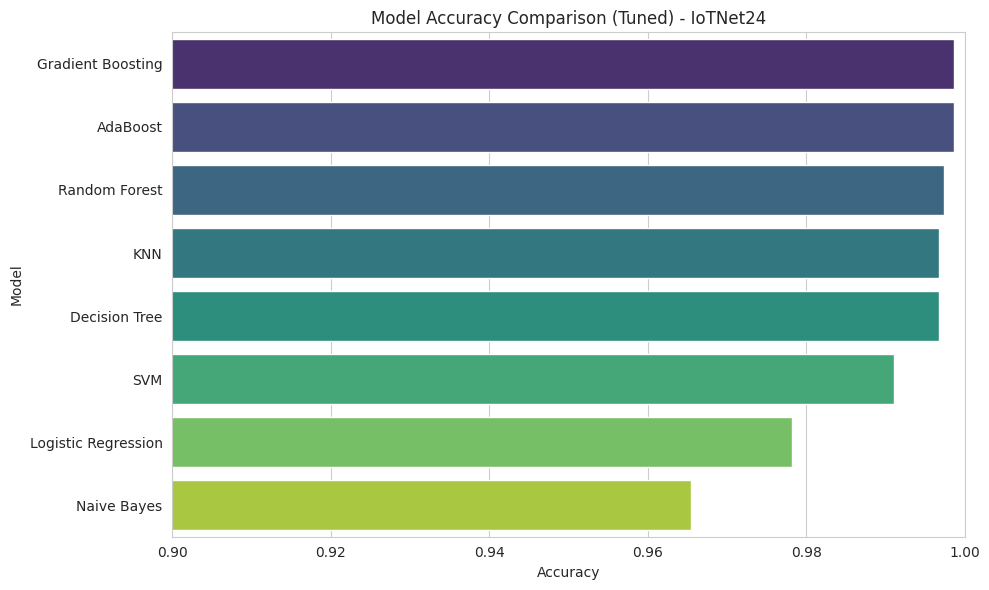

In [31]:
# ============================================
# STEP 17.1: Model Accuracy Comparison (Final Tuned Models)
# ============================================
plt.figure(figsize=(10, 6))
sorted_acc = tuned_df.sort_values(by='Accuracy', ascending=False)
sns.barplot(x='Accuracy', y='Model', data=sorted_acc, palette='viridis')
plt.title('Model Accuracy Comparison (Tuned) - IoTNet24')
plt.xlabel('Accuracy'); plt.ylabel('Model')
plt.xlim(0.9, 1.0)  # zoom in since all models are high
plt.tight_layout()
plt.savefig('iotnet24_accuracy_comparison.png', dpi=150)
plt.show()

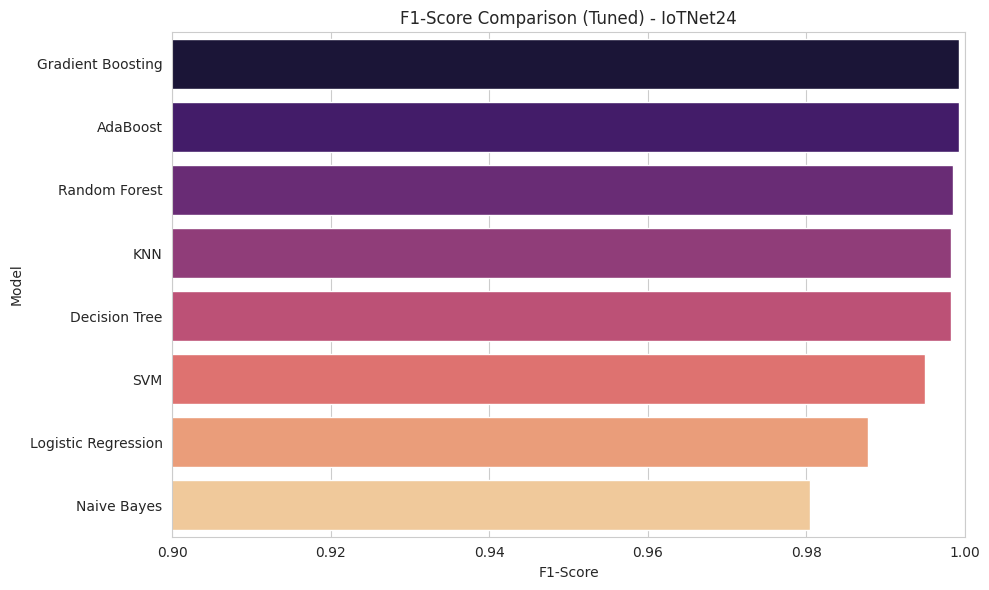

In [32]:
# ============================================
# STEP 17.2: F1-Score Comparison (Final Tuned Models)
# ============================================
plt.figure(figsize=(10, 6))
sorted_f1 = tuned_df.sort_values(by='F1-Score', ascending=False)
sns.barplot(x='F1-Score', y='Model', data=sorted_f1, palette='magma')
plt.title('F1-Score Comparison (Tuned) - IoTNet24')
plt.xlabel('F1-Score'); plt.ylabel('Model')
plt.xlim(0.9, 1.0)
plt.tight_layout()
plt.savefig('iotnet24_f1_comparison.png', dpi=150)
plt.show()

In [33]:
# ============================================
# STEP 18: Save All Models, Scaler, Encoders, Feature Info
# ============================================
for name, model in tuned_models.items():
    filename = 'iotnet24_' + name.lower().replace(' ', '_') + '.pkl'
    joblib.dump(model, os.path.join(local_dir, filename))
    joblib.dump(model, os.path.join(drive_dir, filename))
    print(f"Saved: {filename}")

joblib.dump(scaler, os.path.join(local_dir, 'iotnet24_scaler.pkl'))
joblib.dump(scaler, os.path.join(drive_dir, 'iotnet24_scaler.pkl'))
joblib.dump(le_proto, os.path.join(local_dir, 'iotnet24_proto_encoder.pkl'))
joblib.dump(le_proto, os.path.join(drive_dir, 'iotnet24_proto_encoder.pkl'))
joblib.dump(le_label, os.path.join(local_dir, 'iotnet24_label_encoder.pkl'))
joblib.dump(le_label, os.path.join(drive_dir, 'iotnet24_label_encoder.pkl'))

feature_info = pd.DataFrame({
    'min': X.min(), 'max': X.max(), 'mean': X.mean(), 'dtype': X.dtypes
})
feature_info.to_csv(os.path.join(local_dir, 'iotnet24_feature_info.csv'))
feature_info.to_csv(os.path.join(drive_dir, 'iotnet24_feature_info.csv'))

print("\nAll models, scaler, encoders, and feature info saved (local + Drive).")

Saved: iotnet24_logistic_regression.pkl
Saved: iotnet24_knn.pkl
Saved: iotnet24_naive_bayes.pkl
Saved: iotnet24_decision_tree.pkl
Saved: iotnet24_random_forest.pkl
Saved: iotnet24_svm.pkl
Saved: iotnet24_gradient_boosting.pkl
Saved: iotnet24_adaboost.pkl

All models, scaler, encoders, and feature info saved (local + Drive).


In [34]:
# ============================================
# DOCUMENTATION: Individual Confusion Matrix, ROC, and PR curves per model
# ============================================
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay
import os

os.makedirs('doc_images', exist_ok=True)

def save_individual_cms(model_dict, stage, prefix):
    for name, model in model_dict.items():
        fig, ax = plt.subplots(figsize=(6, 5))
        y_pred = model.predict(X_test_scaled)
        cm = confusion_matrix(y_test, y_pred)
        disp = ConfusionMatrixDisplay(cm)
        disp.plot(ax=ax, cmap='Blues', colorbar=True)
        ax.set_title(f"Confusion Matrix \u2013 {name} ({stage})", fontsize=11)
        plt.tight_layout()
        safe_name = name.lower().replace(' ', '_')
        plt.savefig(f'doc_images/{prefix}_cm_{stage}_{safe_name}.png', dpi=150)
        plt.close(fig)

def save_individual_rocs(model_dict, stage, prefix):
    for name, model in model_dict.items():
        fig, ax = plt.subplots(figsize=(6, 5))
        RocCurveDisplay.from_estimator(model, X_test_scaled, y_test, ax=ax, name=name)
        ax.set_title(f"ROC Curve \u2013 {name} ({stage})", fontsize=11)
        plt.tight_layout()
        safe_name = name.lower().replace(' ', '_')
        plt.savefig(f'doc_images/{prefix}_roc_{stage}_{safe_name}.png', dpi=150)
        plt.close(fig)

def save_individual_prs(model_dict, stage, prefix):
    for name, model in model_dict.items():
        fig, ax = plt.subplots(figsize=(6, 5))
        PrecisionRecallDisplay.from_estimator(model, X_test_scaled, y_test, ax=ax, name=name)
        ax.set_title(f"Precision-Recall Curve \u2013 {name} ({stage})", fontsize=11)
        plt.tight_layout()
        safe_name = name.lower().replace(' ', '_')
        plt.savefig(f'doc_images/{prefix}_pr_{stage}_{safe_name}.png', dpi=150)
        plt.close(fig)

PREFIX = "iotnet24"

# Baseline (8 models x 3 chart types = 24 images)
save_individual_cms(models, "baseline", PREFIX)
save_individual_rocs(models, "baseline", PREFIX)
save_individual_prs(models, "baseline", PREFIX)

# Tuned (8 models x 3 chart types = 24 images)
save_individual_cms(tuned_models, "tuned", PREFIX)
save_individual_rocs(tuned_models, "tuned", PREFIX)
save_individual_prs(tuned_models, "tuned", PREFIX)

print(f"Done. Total images saved: {len(os.listdir('doc_images'))}")

Done. Total images saved: 48


In [35]:
import shutil
from google.colab import files

shutil.make_archive('iotnet24_doc_images_48', 'zip', 'doc_images')
files.download('iotnet24_doc_images_48.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>